## Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

## Loading and Viewing the Dataset

In [3]:
# creating a variable to store the absolute .csv file path for the full Reaxys dataset ("no_numbers" = no Reaxys registry numbers as final column)
reaxys_path = r'C:/Users/Amy/Desktop/Masters_Project/paper_methods/reaxys_dataset/reaxys_data_no_numbers.csv'

# reading in the dataset as stored in the path variable
reaxys = pd.read_csv(reaxys_path)

# printing the index and heading of each column in the dataset
for i, col in enumerate(reaxys.columns):
    print(i, repr(col))

# viewing the shape (no. entries) and title of columns contained by the data
print('Shape:', reaxys.shape)
print('\nColumns:')
for col in reaxys.columns:
    print(repr(col))

# checking for missing values within the dataset
print('\nMissing values:')
print(reaxys.isnull().sum())

0 'Chromophore'
1 'Solvent'
2 'Absorption max (nm)'
3 'log(e/mol-1 dm3 cm-1)'
Shape: (55866, 4)

Columns:
'Chromophore'
'Solvent'
'Absorption max (nm)'
'log(e/mol-1 dm3 cm-1)'

Missing values:
Chromophore              0
Solvent                  0
Absorption max (nm)      0
log(e/mol-1 dm3 cm-1)    0
dtype: int64


#### Comments:
55,866 datapoints in Reaxys representing ~38k chromophores as reported

No missing values in dataset => handy for later analysis

## **Google-Colab-Based Modern Replication**

## Reproducing Figure 2 - Prediction Analysis

In [4]:
# loading test Reaxys dataset and Chemprop predictions obtained utilising the Google Colab
test = pd.read_csv(r'C:/Users/Amy/Desktop/Masters_Project/paper_methods/reaxys_test_filtered_no_reg_nums.csv')
modern_preds = pd.read_csv(r'C:/Users/Amy/Desktop/Masters_Project/paper_methods/modern_chemprop_reaxys/modern_chemprop_reaxys_preds_individual.csv')

In [6]:
# specifying columns within the ensemble/individual prediction outputs file which are related to wavelength and log(molar extinction coefficient),
# respectively
wavelength_cols = [c for c in modern_preds.columns if 'Absorption max (nm)_model_' in c]
log_cols = [c for c in modern_preds.columns if 'log(e/mol-1 dm3 cm-1)_model_' in c]

# converting string values to numeric (float) values for both predicted target properties' columns
modern_preds['Absorption max (nm)'] = (modern_preds[wavelength_cols].astype(float).mean(axis=1))
modern_preds['log(e/mol-1 dm3 cm-1)'] = (modern_preds[log_cols].astype(float).mean(axis=1))

In [8]:
# creating lists to store evaluation metrics for predicted wavelength values
modern_wavelength_rmse = []
modern_wavelength_mae = []

# creating lists to store evaluation metrics for predicted log(molar extinction coefficient) values
modern_log_mec_rmse = []
modern_log_mec_mae = []

# iterating through prediction files
for i in range(5):
    # splitting predicted values for both targets into separate variables
    modern_pred_wavelength = modern_preds[f'Absorption max (nm)_model_{i}']
    modern_pred_log_mec = modern_preds[f'log(e/mol-1 dm3 cm-1)_model_{i}']

    # removing rows where prediction failed and keeping valid rows only
    valid_preds = (modern_preds['Absorption max (nm)'].notna() & modern_preds['log(e/mol-1 dm3 cm-1)'].notna())
    
    # splitting valid true values for wavelength and log(molar extinction coefficient) into separate variables
    true_wavelength = test.loc[valid_preds, 'Absorption max (nm)']
    true_log_mec = test.loc[valid_preds, 'log(e/mol-1 dm3 cm-1)']

    # calculating evaluation metrics for wavelength into separate lists
    modern_wavelength_rmse.append(np.sqrt(mean_squared_error(true_wavelength, modern_pred_wavelength)))
    modern_wavelength_mae.append(mean_absolute_error(true_wavelength, modern_pred_wavelength))

    # calculating evaluation metrics for log(molar extinction coefficient) into separate lists
    modern_log_mec_rmse.append(np.sqrt(mean_squared_error(true_log_mec, modern_pred_log_mec)))
    modern_log_mec_mae.append(mean_absolute_error(true_log_mec, modern_pred_log_mec))

# calculating (ensemble) evaluation metrics for wavelength across all 5 models
ensemble_wavelength_rmse = np.sqrt(mean_squared_error(true_wavelength, modern_preds['Absorption max (nm)']))
ensemble_wavelength_mae = mean_absolute_error(true_wavelength, modern_preds['Absorption max (nm)'])

# calculating (ensemble) evaluation metrics for log(molar extinction coefficient) across all 5 models
ensemble_log_mec_rmse = np.sqrt(mean_squared_error(true_log_mec, modern_preds['log(e/mol-1 dm3 cm-1)']))
ensemble_log_mec_mae = mean_absolute_error(true_log_mec, modern_preds['log(e/mol-1 dm3 cm-1)'])

# calculating (ensemble) standard deviations for both wavelength error metrics across all models
ensemble_wavelength_rmse_sd = np.std(modern_wavelength_rmse)
ensemble_wavelength_mae_sd = np.std(modern_wavelength_mae)

# calculating (ensemble) standard deviations for both log(molar extinction coefficient) error metrics across all models
ensemble_log_mec_rmse_sd = np.std(modern_log_mec_rmse)
ensemble_log_mec_mae_sd = np.std(modern_log_mec_mae)

In [9]:
# printing evaluation metrics for both target properties
print('Modern Reaxys Wavelength RMSE:', ensemble_wavelength_rmse, '+/-', ensemble_wavelength_rmse_sd)
print('Modern Reaxys Wavelength MAE:', ensemble_wavelength_mae, '+/-', ensemble_wavelength_mae_sd)

print('\nModern Reaxys Log(molar extinction coefficient) RMSE:', ensemble_log_mec_rmse, '+/-', ensemble_log_mec_rmse_sd)
print('ModernReaxys Log(molar extinction coefficient) MAE:', ensemble_log_mec_mae,'+/-', ensemble_log_mec_mae_sd)

Modern Reaxys Wavelength RMSE: 37.967934516029615 +/- 0.1828980691660673
Modern Reaxys Wavelength MAE: 20.590837434959628 +/- 0.18690346594031199

Modern Reaxys Log(molar extinction coefficient) RMSE: 0.39258184355273623 +/- 0.002080858934325253
ModernReaxys Log(molar extinction coefficient) MAE: 0.23201433157942516 +/- 0.001823771483335036


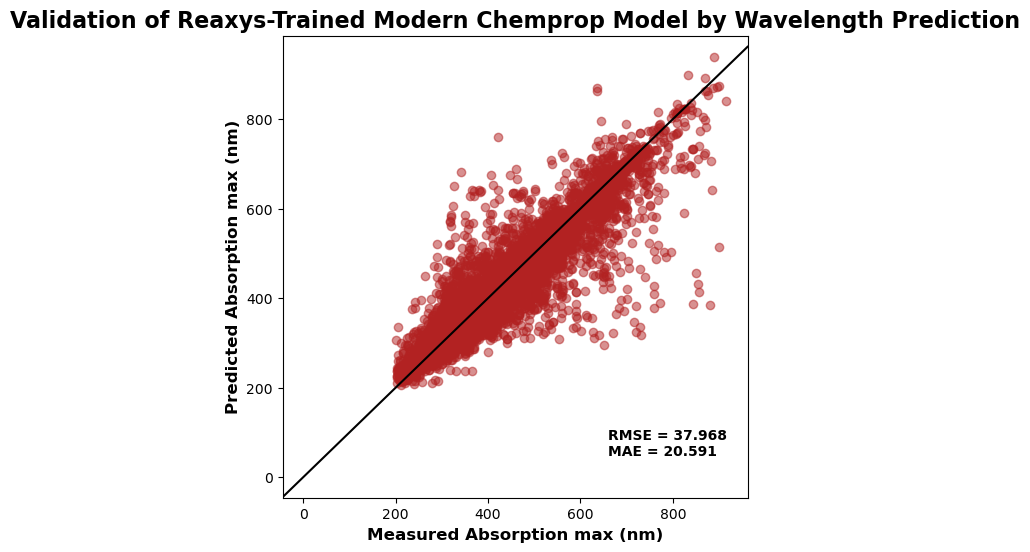

In [10]:
# creating scatter plot to visualise evaluation metrics for wavelength
plt.figure(figsize=(6,6))
plt.scatter(true_wavelength, modern_pred_wavelength, alpha=0.5, color='firebrick')

# adding ideal prediction line (r^2 = 1)
plt.axline((1,1), slope=1, color='black')

# labelling axes
plt.xlabel('Measured Absorption max (nm)', fontsize=12, weight='bold')
plt.ylabel('Predicted Absorption max (nm)', fontsize=12, weight='bold')

# titling plot
plt.title('Validation of Reaxys-Trained Modern Chemprop Model by Wavelength Prediction', fontsize=16, weight='bold')

# adding text to display obtained ensemble evaluation metric values (excluding SDs)
plt.text(0.70, 0.15, f'RMSE = {ensemble_wavelength_rmse:.3f}\nMAE = {ensemble_wavelength_mae:.3f}', transform=plt.gca().transAxes, 
         verticalalignment='top', weight='bold')

plt.show()

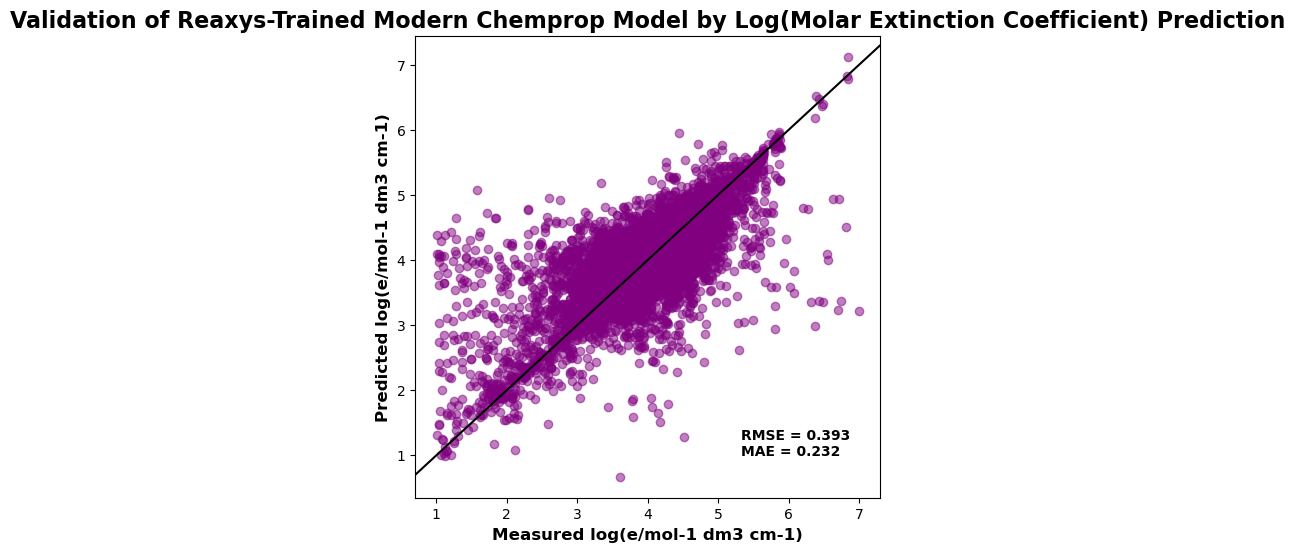

In [11]:
# creating scatter plot to visualise evaluation metrics for molar extinction coefficient
plt.figure(figsize=(6,6))
plt.scatter(true_log_mec, modern_pred_log_mec, alpha=0.5, color='purple')

# adding ideal prediction line (r^2 = 1)
plt.axline((1,1), slope=1, color='black')

# labelling axes
plt.xlabel('Measured log(e/mol-1 dm3 cm-1)', fontsize=12, weight='bold')
plt.ylabel('Predicted log(e/mol-1 dm3 cm-1)', fontsize=12, weight='bold')

# titling plot
plt.title('Validation of Reaxys-Trained Modern Chemprop Model by Log(Molar Extinction Coefficient) Prediction', fontsize=16, weight='bold')

# adding text to display obtained ensemble evaluation metric values (excluding SDs)
plt.text(0.70, 0.15, f'RMSE = {ensemble_log_mec_rmse:.3f}\nMAE = {ensemble_log_mec_mae:.3f}', transform=plt.gca().transAxes, 
         verticalalignment='top', weight='bold')

plt.show()